### **Step 1: Import Libraries and Load Dataset**
This cell imports the necessary Python libraries for data manipulation, visualization, and machine learning. It also loads the `Train_Dataset.csv` and `Test_Dataset.csv` files into pandas DataFrames.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the datasets
try:
    train_df = pd.read_csv('Train_Dataset.csv')
    test_df = pd.read_csv('Test_Dataset.csv')
    print("Datasets loaded. Shape of Train:", train_df.shape)
    display(train_df.head())
except FileNotFoundError:
    print("Error: Make sure 'Train_Dataset.csv' and 'Test_Dataset.csv' are uploaded to your Colab environment.")

/tmp/ipykernel_9652/2804918870.py:12: DtypeWarning: Columns (1,7,8,16,17,18,19,20,35) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv('Train_Dataset.csv')


Datasets loaded. Shape of Train: (121856, 40)


/tmp/ipykernel_9652/2804918870.py:13: DtypeWarning: Columns (7,8,16,17,18,19,20,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv('Test_Dataset.csv')


,ID,Client_Income,Car_Owned,Bike_Owned,Active_Loan,House_Own,Child_Count,Credit_Amount,Loan_Annuity,Accompany_Client,...,Client_Permanent_Match_Tag,Client_Contact_Work_Tag,Type_Organization,Score_Source_1,Score_Source_2,Score_Source_3,Social_Circle_Default,Phone_Change,Credit_Bureau,Default
0,12142509,6750,0.0,0.0,1.0,0.0,0.0,61190.55,3416.85,Alone,...,Yes,Yes,Self-employed,0.568066,0.478787,NaN,0.0186,63.0,NaN,0
1,12138936,20250,1.0,0.0,1.0,NaN,0.0,15282,1826.55,Alone,...,Yes,Yes,Government,0.563360,0.215068,NaN,NaN,NaN,NaN,0
2,12181264,18000,0.0,0.0,1.0,0.0,1.0,59527.35,2788.2,Alone,...,Yes,Yes,Self-employed,NaN,0.552795,0.329655,0.0742,277.0,0.0,0
3,12188929,15750,0.0,0.0,1.0,1.0,0.0,53870.4,2295.45,Alone,...,Yes,Yes,XNA,NaN,0.135182,0.631355,NaN,1700.0,3.0,0
4,12133385,33750,1.0,0.0,1.0,0.0,2.0,133988.4,3547.35,Alone,...,Yes,Yes,Business Entity Type 3,0.508199,0.301182,0.355639,0.2021,674.0,1.0,0


### **Step 2: Data Preprocessing**
This step handles missing values by filling numeric columns with their median and categorical columns with their mode. It then encodes categorical variables into numerical format using `LabelEncoder`, defines features (X) and target (y), splits the training data for validation, and scales the features using `StandardScaler`.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split # Ensure this import is here

# 1. Robust Handling of Mixed Types and Missing Values for both train_df and test_df
for df_ref in [train_df, test_df]:
    for col in df_ref.columns:
        if col == 'ID' or (df_ref is test_df and col == 'Default'): # Skip ID and target for test_df
            continue

        # Attempt to convert column to numeric. Non-numeric values (like '#') will become NaN.
        df_ref[col] = pd.to_numeric(df_ref[col], errors='coerce')

        # Now handle missing values based on the *current* dtype
        if pd.api.types.is_numeric_dtype(df_ref[col]):
            median_val = df_ref[col].median()
            if pd.isna(median_val): # If median is NaN (e.g., column was all NaNs), fill with 0
                df_ref[col] = df_ref[col].fillna(0)
            else:
                df_ref[col] = df_ref[col].fillna(median_val)
        else: # Must be an object type that couldn't be converted to numeric
            mode_val = df_ref[col].mode()[0]
            df_ref[col] = df_ref[col].fillna(mode_val)

# Handle NaN values in the 'Default' column specifically for train_df
# It's generally best to drop rows where the target variable is missing.
if 'Default' in train_df.columns:
    initial_train_rows = train_df.shape[0]
    train_df.dropna(subset=['Default'], inplace=True)
    if train_df.shape[0] < initial_train_rows:
        print(f"Dropped {initial_train_rows - train_df.shape[0]} rows from train_df due to NaN in 'Default' column.")

    # Ensure 'Default' is numeric after dropping NaNs, if it wasn't already
    train_df['Default'] = pd.to_numeric(train_df['Default'], errors='coerce')
    # If for some reason any NaNs remain (e.g., if it became NaN during to_numeric), fill with 0
    train_df['Default'] = train_df['Default'].fillna(0).astype(int)


# 2. Encoding Categorical Variables
# Re-identify categorical columns (those still of object dtype) after robust handling
le = LabelEncoder()
categorical_cols_to_encode = train_df.select_dtypes(include=['object']).columns

for col in categorical_cols_to_encode:
    if col == 'ID' or (col == 'Default' and 'Default' in train_df.columns):
        continue

    # Convert to string for LabelEncoder
    train_df[col] = train_df[col].astype(str)
    le.fit(train_df[col])
    train_df[col] = le.transform(train_df[col])

    if col in test_df.columns:
        test_df[col] = test_df[col].astype(str)
        # Map test set categories using the encoder fitted on the training set.
        # Assign -1 for any categories in the test set not seen in the training set.
        classes_mapping = {label: idx for idx, label in enumerate(le.classes_)}
        test_df[col] = test_df[col].map(classes_mapping).fillna(-1).astype(int)

# 3. Defining Features (X) and Target (y)
X = train_df.drop(['ID', 'Default'], axis=1)
y = train_df['Default']

# 4. Splitting for Internal Validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print("Preprocessing complete: Missing values handled, data encoded, and scaled.")

Preprocessing complete: Missing values handled, data encoded, and scaled.


### **Step 3: Model Training**
This cell initializes and trains the Logistic Regression algorithm using the preprocessed training data.

In [3]:
# Initialize the Logistic Regression model
# Using 'liblinear' solver which is good for small to medium datasets
log_reg = LogisticRegression(solver='liblinear', max_iter=1000)

# Train the model
log_reg.fit(X_train, y_train)

print("Logistic Regression model training finished.")

Logistic Regression model training finished.


### **Step 4: Check Accuracy and Performance**
This part calculates the accuracy of the trained model on the validation set, provides a detailed classification report, and visualizes the confusion matrix.

Model Accuracy: 92.01%

Classification Report:
              precision    recall  f1-score   support

           0       0.92      1.00      0.96     22425
           1       0.50      0.00      0.00      1947

    accuracy                           0.92     24372
   macro avg       0.71      0.50      0.48     24372
weighted avg       0.89      0.92      0.88     24372



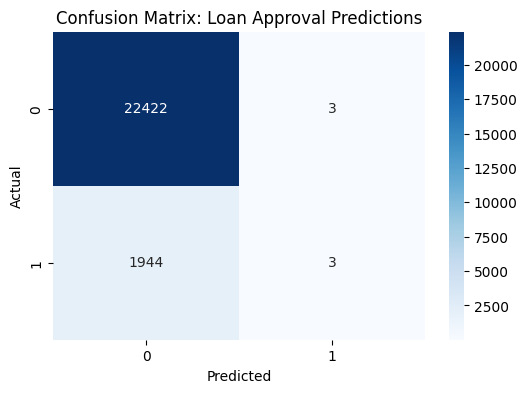

In [4]:
# Make predictions on the validation set
y_pred = log_reg.predict(X_val)

# Calculate Accuracy Percentage
accuracy = accuracy_score(y_val, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Detailed metrics
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Loan Approval Predictions')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### **Step 5: Output Generation for Test Dataset**
This cell applies the trained model to the `Test_Dataset.csv` to generate the final predictions, creates an output DataFrame with 'ID' and 'Predicted_Default_Status', and saves it to `Loan_Approval_Predictions.csv`.

In [5]:
# Prepare the test features
X_test = test_df.drop(['ID'], axis=1)

# Ensure all columns are numeric for scaling, handling any unexpected remaining non-numeric data.
# This acts as a final safeguard.
for col in X_test.columns:
    if not pd.api.types.is_numeric_dtype(X_test[col]):
        X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
        X_test[col] = X_test[col].fillna(X_test[col].median() if not X_test[col].isnull().all() else 0)

X_test_scaled = scaler.transform(X_test)

# Generate predictions
test_preds = log_reg.predict(X_test_scaled)

# Create a final dataframe for the output
output = pd.DataFrame({
    'ID': test_df['ID'],
    'Predicted_Default_Status': test_preds
})

# Save to CSV
output.to_csv('Loan_Approval_Predictions.csv', index=False)

print("Predictions for the test dataset have been saved to 'Loan_Approval_Predictions.csv'.")
display(output.head())

Predictions for the test dataset have been saved to 'Loan_Approval_Predictions.csv'.


,ID,Predicted_Default_Status
0,12202227,0
1,12279381,0
2,12222714,0
3,12265215,0
4,12203970,0
